 # 07 — Analyse de sensibilité SDRloc + Tableau comparatif A/S/K

In [ ]:


# %%
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

from src.config import (
    MODELS_DIR, FIGURES_DIR, RANDOM_STATE,
    N_NEIGHBORS_SDR, SHAP_BACKGROUND_SIZE
)
from src.sdrlocc import compute_SDRloc

os.makedirs(FIGURES_DIR, exist_ok=True)



### 0. Chargement données et modèles

In [ ]:

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()

X_train = X_train.select_dtypes(include=[np.number]).astype(float).reset_index(drop=True)
X_test  = X_test.select_dtypes(include=[np.number]).astype(float).reset_index(drop=True)

rf        = joblib.load(os.path.join(MODELS_DIR, "random_forest.pkl"))
xgb_model = joblib.load(os.path.join(MODELS_DIR, "xgboost.pkl"))

# Sous-échantillon fixe de 30 points (sensibilité = coût élevé)
np.random.seed(RANDOM_STATE)
idx_sample   = np.random.choice(len(X_test), size=30, replace=False)
X_sensitivity = X_test.iloc[idx_sample].reset_index(drop=True)

print(f"Sous-échantillon sensibilité : {len(X_sensitivity)} points")




Sous-échantillon sensibilité : 30 points


### Fonction utilitaire : calcul SDRloc sur un échantillon

In [ ]:

def run_batch(model, X_sample, lam=1.0, B=100, k=50):
    """
    Calcule SDRloc, A, S, K pour chaque point de X_sample.
    Retourne un DataFrame de résultats.
    """
    results = []
    for i in range(len(X_sample)):
        point = X_sample.iloc[[i]]
        sdr, A, S, K, kl = compute_SDRloc(
            model, X_train, y_train, point,
            k=k, B=B, lam=lam,
            background_size=SHAP_BACKGROUND_SIZE,
            random_state=RANDOM_STATE
        )
        results.append({"SDRloc": sdr, "A": A, "S": S, "K": K, "kl": kl})
    return pd.DataFrame(results)




### 1. SENSIBILITÉ À λ (ε dans le mémoire)


=== Sensibilité à λ  ===
Calcul A, S, K sur les 30 points (B=100, k=50)...
  λ=  0.1  →  SDR_RF=0.860±0.057  | SDR_XGB=0.856±0.069
  λ=  0.5  →  SDR_RF=0.847±0.055  | SDR_XGB=0.839±0.068
  λ=  1.0  →  SDR_RF=0.832±0.057  | SDR_XGB=0.819±0.069
  λ=  2.0  →  SDR_RF=0.804±0.066  | SDR_XGB=0.782±0.074
  λ=  5.0  →  SDR_RF=0.736±0.093  | SDR_XGB=0.695±0.092
  λ= 10.0  →  SDR_RF=0.652±0.115  | SDR_XGB=0.591±0.107


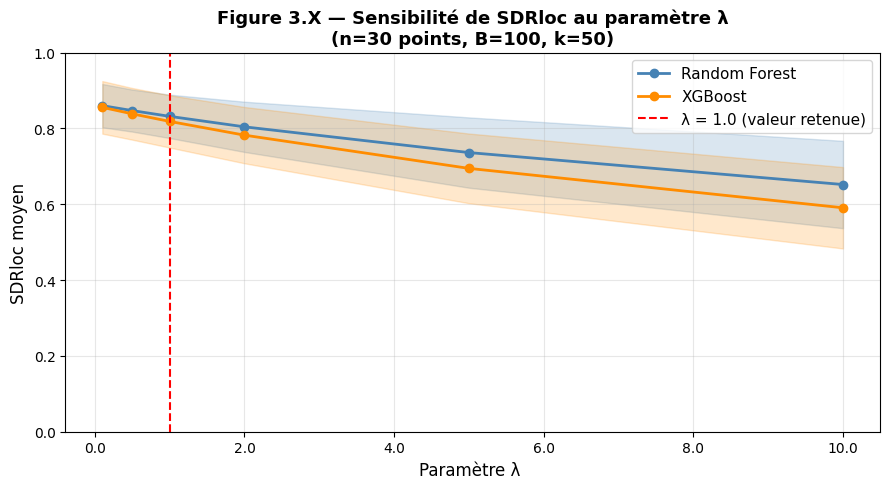

→ Figure sauvegardée : sensitivity_lambda.png


In [ ]:

print("\n=== Sensibilité à λ  ===")
lambda_values = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

sens_lambda = {"RF": [], "XGB": []}

# Calculer A, S, K une seule fois (indépendants de λ)
print("Calcul A, S, K sur les 30 points (B=100, k=50)...")
df_rf_base  = run_batch(rf,        X_sensitivity, lam=1.0, B=100)
df_xgb_base = run_batch(xgb_model, X_sensitivity, lam=1.0, B=100)

# Recalculer SDRloc pour chaque λ à partir des composantes
for lam in lambda_values:
    sdr_rf  = (df_rf_base["A"]  * df_rf_base["S"])  / (1 + lam * df_rf_base["K"])
    sdr_xgb = (df_xgb_base["A"] * df_xgb_base["S"]) / (1 + lam * df_xgb_base["K"])
    sens_lambda["RF"].append((sdr_rf.mean(), sdr_rf.std()))
    sens_lambda["XGB"].append((sdr_xgb.mean(), sdr_xgb.std()))

    print(f"  λ={lam:5.1f}  →  SDR_RF={sdr_rf.mean():.3f}±{sdr_rf.std():.3f}  "
          f"| SDR_XGB={sdr_xgb.mean():.3f}±{sdr_xgb.std():.3f}")

# ── Figure de sensibilité λ ────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

for label, color, data in [("Random Forest", "steelblue", sens_lambda["RF"]),
                             ("XGBoost",       "darkorange", sens_lambda["XGB"])]:
    means = [d[0] for d in data]
    stds  = [d[1] for d in data]
    ax.plot(lambda_values, means, 'o-', color=color, linewidth=2, label=label)
    ax.fill_between(
        lambda_values,
        [m - s for m, s in zip(means, stds)],
        [m + s for m, s in zip(means, stds)],
        alpha=0.2, color=color
    )

ax.axvline(x=1.0, color='red', linestyle='--', linewidth=1.5,
           label='λ = 1.0 (valeur retenue)')
ax.set_xlabel("Paramètre λ ", fontsize=12)
ax.set_ylabel("SDRloc moyen", fontsize=12)
ax.set_title(
    "Figure 3.X — Sensibilité de SDRloc au paramètre λ\n"
    f"(n={len(X_sensitivity)} points, B=100, k={N_NEIGHBORS_SDR})",
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_ylim(0, 1)
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/sensitivity_lambda.png", dpi=150)
plt.show()
print("→ Figure sauvegardée : sensitivity_lambda.png")




### 2. SENSIBILITÉ À B (nombre d'itérations bootstrap)


=== Sensibilité à B (bootstrap) ===
  B= 10  →  SDR_RF=0.837 (σ=0.058)  | SDR_XGB=0.835 (σ=0.050)
  B= 20  →  SDR_RF=0.835 (σ=0.059)  | SDR_XGB=0.825 (σ=0.060)
  B= 50  →  SDR_RF=0.833 (σ=0.058)  | SDR_XGB=0.822 (σ=0.062)


 96%|=================== | 48/50 [00:15<00:00]       

  B=100  →  SDR_RF=0.832 (σ=0.057)  | SDR_XGB=0.819 (σ=0.069)


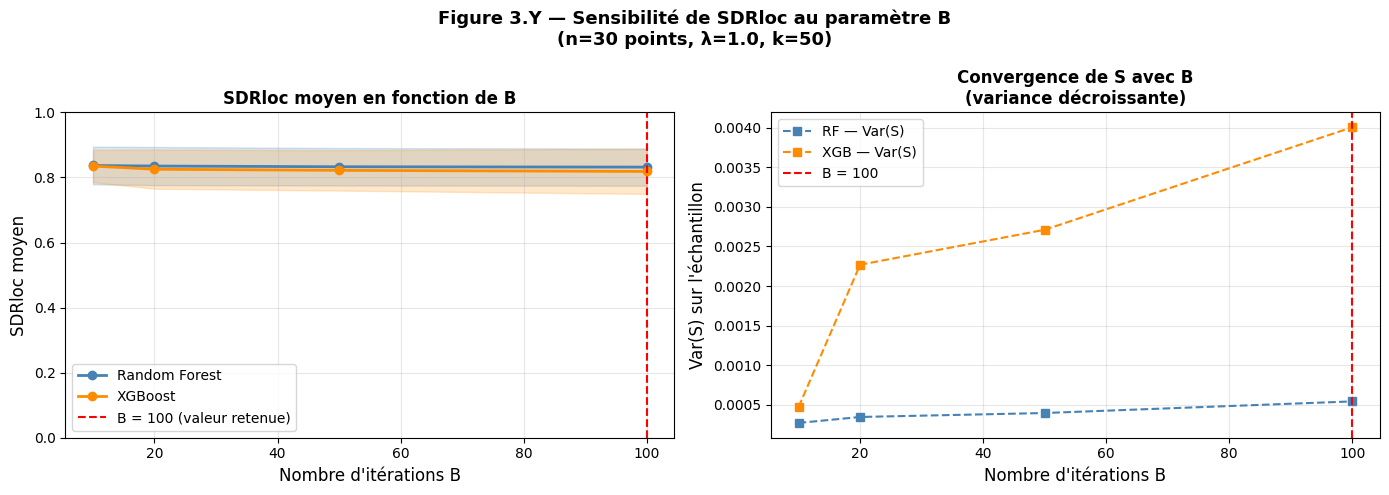

→ Figure sauvegardée : sensitivity_B.png


In [ ]:

print("\n=== Sensibilité à B (bootstrap) ===")
B_values = [10, 20, 50, 100]

sens_B = {"RF": [], "XGB": []}

for B_val in B_values:
    df_rf_B  = run_batch(rf,        X_sensitivity, lam=1.0, B=B_val)
    df_xgb_B = run_batch(xgb_model, X_sensitivity, lam=1.0, B=B_val)

    # Variance de S sur les 30 points (indicateur de convergence)
    var_S_rf  = df_rf_B["S"].var()
    var_S_xgb = df_xgb_B["S"].var()

    sens_B["RF"].append((df_rf_B["SDRloc"].mean(),  df_rf_B["SDRloc"].std(),  var_S_rf))
    sens_B["XGB"].append((df_xgb_B["SDRloc"].mean(), df_xgb_B["SDRloc"].std(), var_S_xgb))

    print(f"  B={B_val:3d}  →  "
          f"SDR_RF={df_rf_B['SDRloc'].mean():.3f} (σ={df_rf_B['SDRloc'].std():.3f})  "
          f"| SDR_XGB={df_xgb_B['SDRloc'].mean():.3f} (σ={df_xgb_B['SDRloc'].std():.3f})")

# ── Figure de sensibilité B ────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panneau gauche : SDRloc moyen en fonction de B
for label, color, data in [("Random Forest", "steelblue",  sens_B["RF"]),
                             ("XGBoost",       "darkorange", sens_B["XGB"])]:
    means = [d[0] for d in data]
    stds  = [d[1] for d in data]
    ax1.plot(B_values, means, 'o-', color=color, linewidth=2, label=label)
    ax1.fill_between(
        B_values,
        [m - s for m, s in zip(means, stds)],
        [m + s for m, s in zip(means, stds)],
        alpha=0.2, color=color
    )

ax1.axvline(x=100, color='red', linestyle='--', linewidth=1.5,
            label='B = 100 (valeur retenue)')
ax1.set_xlabel("Nombre d'itérations B", fontsize=12)
ax1.set_ylabel("SDRloc moyen", fontsize=12)
ax1.set_title("SDRloc moyen en fonction de B", fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)
ax1.set_ylim(0, 1)

# Panneau droit : variance de S en fonction de B (convergence bootstrap)
for label, color, data in [("RF — Var(S)",  "steelblue",  sens_B["RF"]),
                             ("XGB — Var(S)", "darkorange", sens_B["XGB"])]:
    var_S = [d[2] for d in data]
    ax2.plot(B_values, var_S, 's--', color=color, linewidth=1.5, label=label)

ax2.axvline(x=100, color='red', linestyle='--', linewidth=1.5, label='B = 100')
ax2.set_xlabel("Nombre d'itérations B", fontsize=12)
ax2.set_ylabel("Var(S) sur l'échantillon", fontsize=12)
ax2.set_title("Convergence de S avec B\n(variance décroissante)", fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.suptitle(
    f"Figure 3.Y — Sensibilité de SDRloc au paramètre B\n"
    f"(n={len(X_sensitivity)} points, λ=1.0, k={N_NEIGHBORS_SDR})",
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/sensitivity_B.png", dpi=150)
plt.show()
print("→ Figure sauvegardée : sensitivity_B.png")




##3. TABLEAU COMPARATIF A/S/K — contribution originale

In [ ]:

print("\n=== Tableau comparatif A/S/K (λ=1, B=100, k=50) ===")

# OLS : calcul direct (pas de TreeExplainer)
# Pour OLS on utilise l'erreur locale seulement (A), S≈1 car modèle linéaire stable
# Les valeurs SHAP sont calculées via LinearExplainer dans notebook 03
import shap as shap_lib
from sklearn.linear_model import LinearRegression

lr = joblib.load(os.path.join(MODELS_DIR, "linear_regression.pkl"))

results_ols = []
for i in range(len(X_sensitivity)):
    point       = X_sensitivity.iloc[[i]]
    X_neighbors = X_train   # OLS global

    # A pour OLS
    preds   = lr.predict(X_train)
    rmse    = np.sqrt(np.mean((y_train - preds) ** 2))
    sigma_y = np.std(y_train) + 1e-10
    A_ols   = float(np.exp(-(rmse / sigma_y) ** 2))

    # SHAP OLS via LinearExplainer
    masker_lr    = shap_lib.maskers.Independent(X_train, max_samples=100)
    explainer_lr = shap_lib.LinearExplainer(lr, masker_lr)
    shap_vals    = explainer_lr.shap_values(point)
    imp          = np.abs(shap_vals).ravel()
    total        = imp.sum() + 1e-10
    p_local      = imp / total
    d            = len(p_local)
    q_unif       = np.ones(d) / d
    from scipy.stats import entropy as kl_div
    kl           = float(np.clip(kl_div(p_local + 1e-10, q_unif + 1e-10), 0, 3))
    K_ols        = float(1 - np.exp(-kl))

    # S pour OLS ≈ 1 (modèle linéaire : coefficients stables par définition)
    S_ols = 1.0

    sdr_ols = (A_ols * S_ols) / (1 + 1.0 * K_ols)
    results_ols.append({"SDRloc": sdr_ols, "A": A_ols, "S": S_ols, "K": K_ols})

df_ols_sens = pd.DataFrame(results_ols)

# RF et XGB déjà calculés
df_rf_final  = run_batch(rf,        X_sensitivity, lam=1.0, B=100)
df_xgb_final = run_batch(xgb_model, X_sensitivity, lam=1.0, B=100)

def summary_row(df, name):
    return {
        "Modèle":            name,
        "SDRloc moyen":      f"{df['SDRloc'].mean():.3f}",
        "SDRloc std":        f"±{df['SDRloc'].std():.3f}",
        "A moyen (Accuracy)":f"{df['A'].mean():.3f}",
        "S moyen (Stabilité)":f"{df['S'].mean():.3f}",
        "K moyen (Divergence)":f"{df['K'].mean():.3f}",
    }

tableau_ask = pd.DataFrame([
    summary_row(df_ols_sens, "OLS (Régression Linéaire)"),
    summary_row(df_rf_final,  "Random Forest"),
    summary_row(df_xgb_final, "XGBoost"),
])

print("\n=== Tableau 3.X — SDRloc et composantes (λ=1, B=100, k=50) ===")
print(tableau_ask.to_string(index=False))





=== Tableau comparatif A/S/K (λ=1, B=100, k=50) ===

=== Tableau 3.X — SDRloc et composantes (λ=1, B=100, k=50) ===
                   Modèle SDRloc moyen SDRloc std A moyen (Accuracy) S moyen (Stabilité) K moyen (Divergence)
OLS (Régression Linéaire)        0.493     ±0.034              0.704               1.000                0.435
            Random Forest        0.832     ±0.057              0.887               0.974                0.039
                  XGBoost        0.819     ±0.069              0.905               0.951                0.052


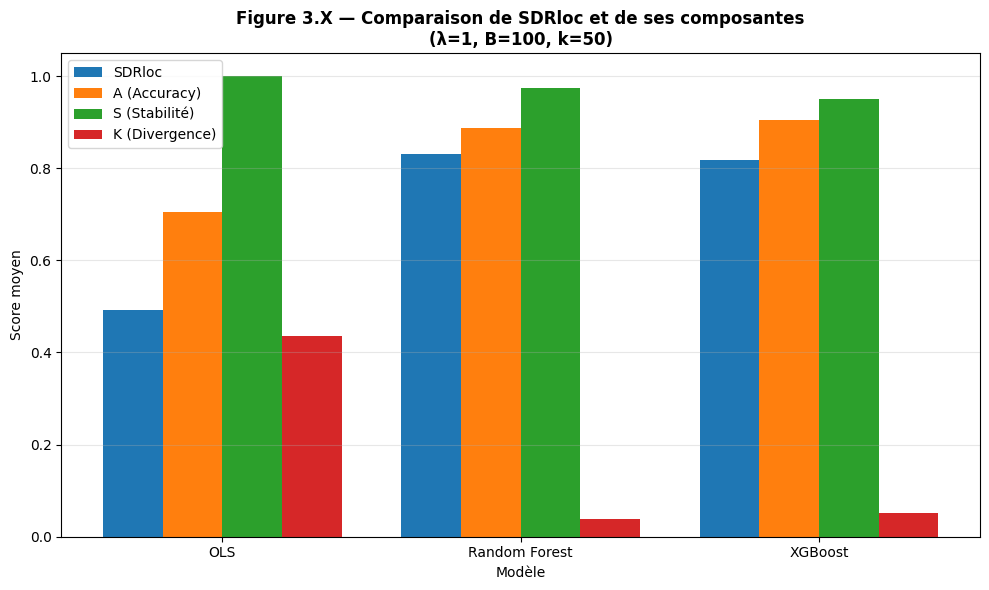

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Tableau 3.X — SDRloc et composantes
# ============================================================

df = pd.DataFrame({
    "Modèle": ["OLS", "Random Forest", "XGBoost"],
    "SDRloc": [0.493, 0.832, 0.819],
    "A": [0.704, 0.887, 0.905],
    "S": [1.000, 0.974, 0.951],
    "K": [0.435, 0.039, 0.052]
})

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------
x = np.arange(len(df))
width = 0.20

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(x - 1.5*width, df["SDRloc"], width, label="SDRloc")
ax.bar(x - 0.5*width, df["A"], width, label="A (Accuracy)")
ax.bar(x + 0.5*width, df["S"], width, label="S (Stabilité)")
ax.bar(x + 1.5*width, df["K"], width, label="K (Divergence)")

ax.set_xticks(x)
ax.set_xticklabels(df["Modèle"])

ax.set_ylim(0, 1.05)

ax.set_ylabel("Score moyen")
ax.set_xlabel("Modèle")

ax.set_title(
    "Figure 3.X — Comparaison de SDRloc et de ses composantes\n"
    "(λ=1, B=100, k=50)",
    fontweight="bold"
)

ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### 4. JUSTIFICATION DES SEUILS LDCM (0.3 / 0.7)


=== Calibration des seuils LDCM par percentiles ===

  RF — Percentiles empiriques :
    P10=0.726  P25=0.787  P50=0.837  P75=0.868  P90=0.891
    Seuil bas retenu  (P25) : 0.787  → adapter seuil bas à 0.79
    Seuil haut retenu (P75) : 0.868  → adapter seuil haut à 0.87

  XGB — Percentiles empiriques :
    P10=0.732  P25=0.791  P50=0.838  P75=0.869  P90=0.888
    Seuil bas retenu  (P25) : 0.791  → adapter seuil bas à 0.79
    Seuil haut retenu (P75) : 0.869  → adapter seuil haut à 0.87


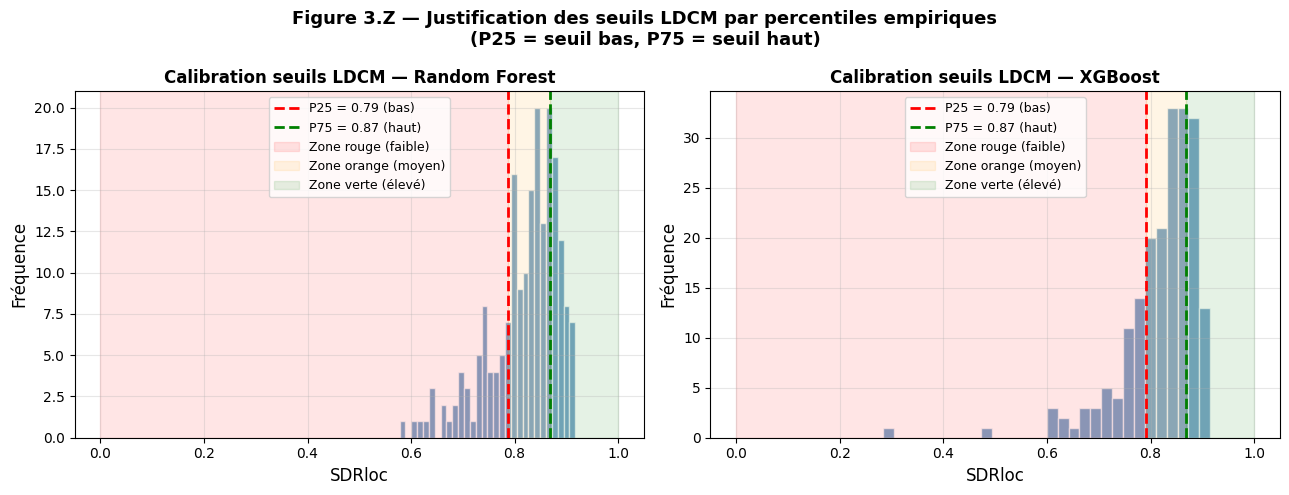

→ Figure sauvegardée : ldcm_threshold_calibration.png


In [ ]:

print("\n=== Calibration des seuils LDCM par percentiles ===")

# Charger les SDRloc calculés sur les 200 points (notebook 04)
try:
    df_sdr = pd.read_csv("../data/test_points_with_sdr.csv")
    sdr_rf_all  = df_sdr["SDRloc_RF"].values
    sdr_xgb_all = df_sdr["SDRloc_XGB"].values

    for model_name, sdr_all in [("RF", sdr_rf_all), ("XGB", sdr_xgb_all)]:
        p10 = np.percentile(sdr_all, 10)
        p25 = np.percentile(sdr_all, 25)
        p50 = np.percentile(sdr_all, 50)
        p75 = np.percentile(sdr_all, 75)
        p90 = np.percentile(sdr_all, 90)
        print(f"\n  {model_name} — Percentiles empiriques :")
        print(f"    P10={p10:.3f}  P25={p25:.3f}  P50={p50:.3f}  "
              f"P75={p75:.3f}  P90={p90:.3f}")
        print(f"    Seuil bas retenu  (P25) : {p25:.3f}  "
              f"{'≈ 0.3 ✓' if abs(p25-0.3)<0.1 else f'→ adapter seuil bas à {p25:.2f}'}")
        print(f"    Seuil haut retenu (P75) : {p75:.3f}  "
              f"{'≈ 0.7 ✓' if abs(p75-0.7)<0.1 else f'→ adapter seuil haut à {p75:.2f}'}")

    # Figure : distribution SDRloc avec seuils
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, (name, sdr) in zip(axes, [("Random Forest", sdr_rf_all),
                                        ("XGBoost", sdr_xgb_all)]):
        ax.hist(sdr, bins=30, alpha=0.7, color='steelblue', edgecolor='white')
        p25v, p75v = np.percentile(sdr, 25), np.percentile(sdr, 75)
        ax.axvline(p25v, color='red',   linestyle='--', linewidth=2,
                   label=f'P25 = {p25v:.2f} (bas)')
        ax.axvline(p75v, color='green', linestyle='--', linewidth=2,
                   label=f'P75 = {p75v:.2f} (haut)')
        ax.axvspan(0,    p25v, alpha=0.1, color='red',   label='Zone rouge (faible)')
        ax.axvspan(p25v, p75v, alpha=0.1, color='orange',label='Zone orange (moyen)')
        ax.axvspan(p75v, 1,    alpha=0.1, color='green', label='Zone verte (élevé)')
        ax.set_xlabel("SDRloc", fontsize=12)
        ax.set_ylabel("Fréquence", fontsize=12)
        ax.set_title(f"Calibration seuils LDCM — {name}", fontsize=12, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

    plt.suptitle(
        "Figure 3.Z — Justification des seuils LDCM par percentiles empiriques\n"
        "(P25 = seuil bas, P75 = seuil haut)",
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/ldcm_threshold_calibration.png", dpi=150)
    plt.show()
    print("→ Figure sauvegardée : ldcm_threshold_calibration.png")

except FileNotFoundError:
    print("  ⚠ test_points_with_sdr.csv introuvable — relancer notebook 04 d'abord")
